In [10]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
diabetes_data = pd.read_csv('diabetes.csv')


# Separate features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

In [2]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the XGBoost model with basic hyperparameters
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define a hyperparameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

In [7]:
# Perform GridSearchCV for hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='accuracy', cv=cv, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model and parameters
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the model on the test set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Display results
print(f"Test Accuracy: {accuracy:.2f}")
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(classification_rep)


Fitting 5 folds for each of 972 candidates, totalling 4860 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:07:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1.0}
Test Accuracy: 0.81
Confusion Matrix:
[[79 21]
 [16 84]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.80      0.84      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200




Test Accuracy of the logistic regression model: 81.50%

Confusion Matrix:
[[79 21]
 [16 84]]


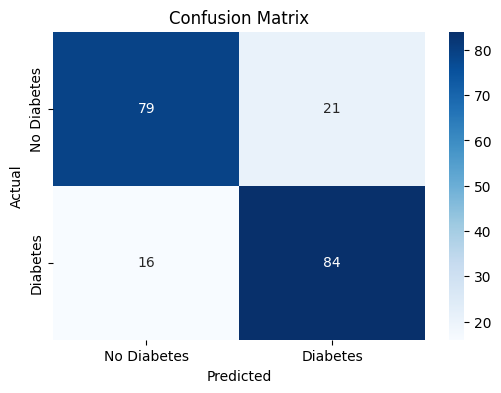

In [11]:
# Model Evaluation
print(f"\nTest Accuracy of the logistic regression model: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualizing the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


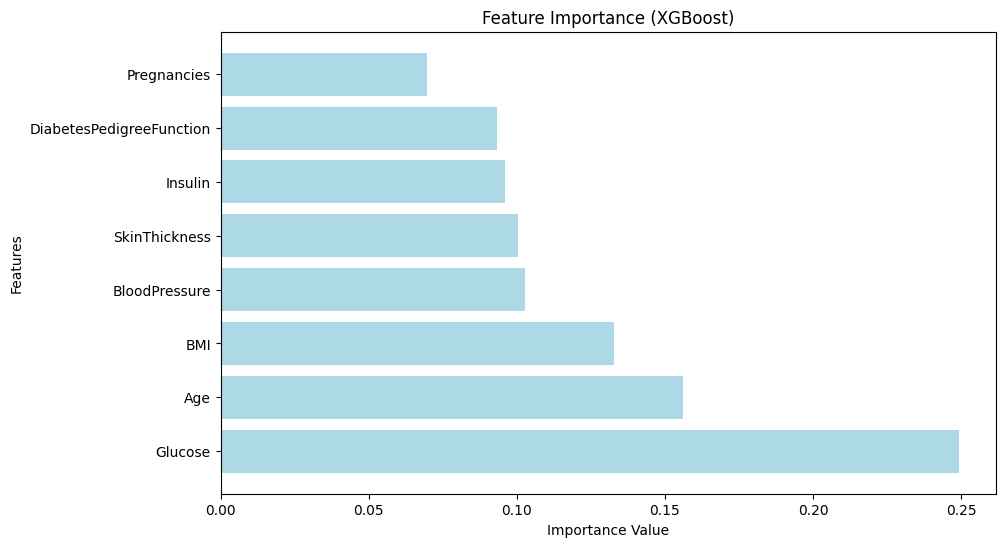

In [20]:
# Analyzing feature importance
importance = best_model.feature_importances_
feature_names = diabetes_data.columns[:-1]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df['Absolute_Importance'] = np.abs(importance_df['Importance'])
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightblue')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.show()



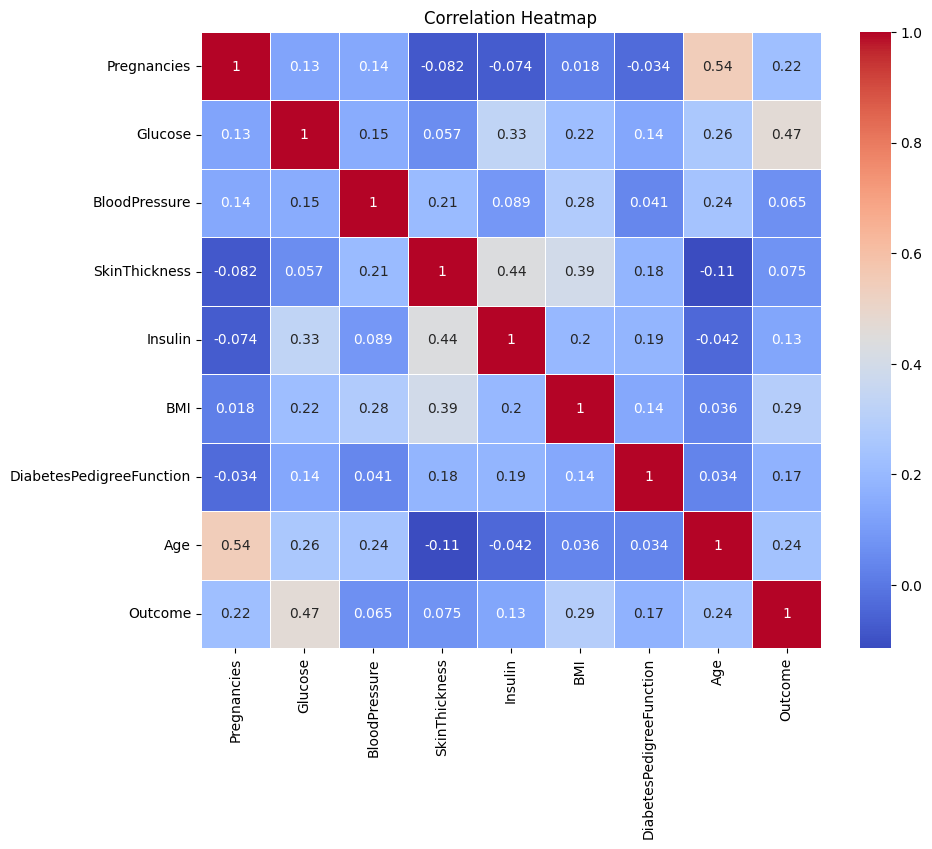

In [21]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()